In [41]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

import numpy as np
import matplotlib.pyplot as plt

In [42]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

In [43]:
X,y = make_regression(n_samples=100,n_features=1, n_informative=1, n_targets=1, noise=20, random_state=13)

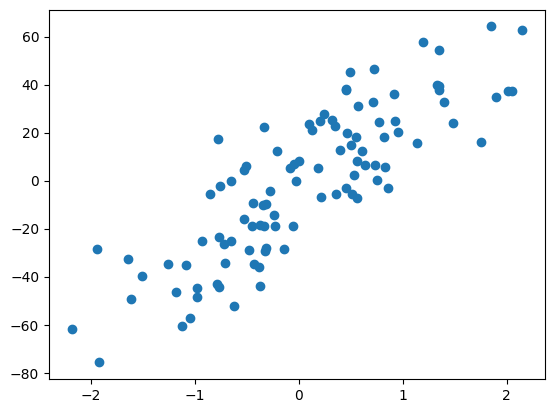

In [44]:
plt.scatter(X,y)

In [45]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [46]:
import time
b = 150
m = -127.82
all_b =[]
all_m =[]
all_cost = []
all_lr =[]

epochs =1
start = time.time()

t0,t1 = 5,50
def learning_rate(t):
    return t0/(t + t1)

for i in range(epochs):
    for j in range(X.shape[0]):

        lr = learning_rate(i * X.shape[0] + j)

        idx = np.random.randint(X.shape[0], size=1)

        slope_b = -2 * (y[idx] - (m * X[idx]) -  b)
        slope_m = -2 * (y[idx] - (m * X[idx]) -  b) * X[idx]
        cost = (y[idx] - m * X[idx] -b) ** 2
        
        
        b = b - (lr * slope_b)
        m = m - (lr * slope_m)
        all_b.append(b)
        all_m.append(m)
        all_cost.append(cost)
        all_lr.append(lr)
        
print("Total time taken",time.time() - start)

Total time taken 0.01570272445678711


In [47]:
len(all_cost)

100

C:\Users\KESHAV\AppData\Local\Temp\ipykernel_27396\1816557387.py:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(all_m[0]) * x_i + float(all_b[0]),
C:\Users\KESHAV\AppData\Local\Temp\ipykernel_27396\1816557387.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m = float(all_m[i])
C:\Users\KESHAV\AppData\Local\Temp\ipykernel_27396\1816557387.py:20: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  b = float(all_b[i])


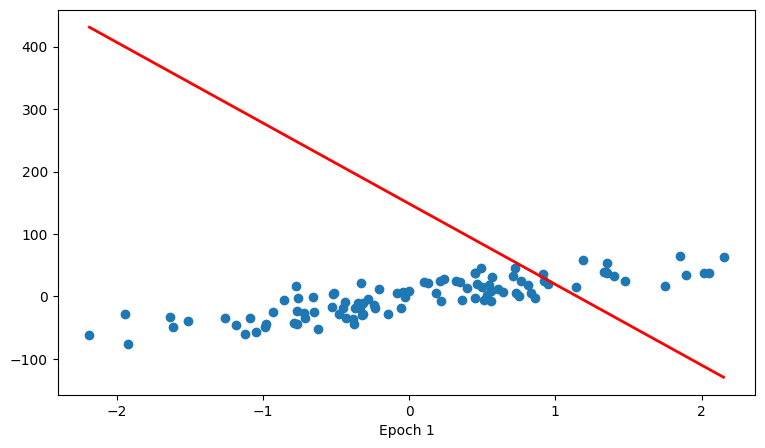

In [54]:
fig, ax = plt.subplots(figsize=(9,5))

# Flatten X if it is (n,1)
X_plot = X.ravel()

ax.scatter(X_plot, y)

x_i = np.linspace(X_plot.min(), X_plot.max(), 100)

# Initial regression line
line, = ax.plot(
    x_i,
    float(all_m[0]) * x_i + float(all_b[0]),
    'r-',
    linewidth=2
)

def update(i):
    m = float(all_m[i])
    b = float(all_b[i])
    line.set_ydata(m * x_i + b)
    ax.set_xlabel(f"Epoch {i+1}")
    return line,

anim = FuncAnimation(fig, update, frames=len(all_m), interval=100, blit=True)

plt.show()

In [49]:
m_arr = np.linspace(-150, 150, 10)
b_arr = np.linspace(-150, 150, 10)
mGrid, bGrid = np.meshgrid(m_arr,b_arr)

final = np.vstack((mGrid.ravel().reshape(1,100),bGrid.ravel().reshape(1,100))).T

z_arr = []

for i in range(final.shape[0]):
    z_arr.append(np.sum((y - final[i,0]*X.reshape(100) - final[i,1])**2))

z_arr = np.array(z_arr).reshape(10,10)

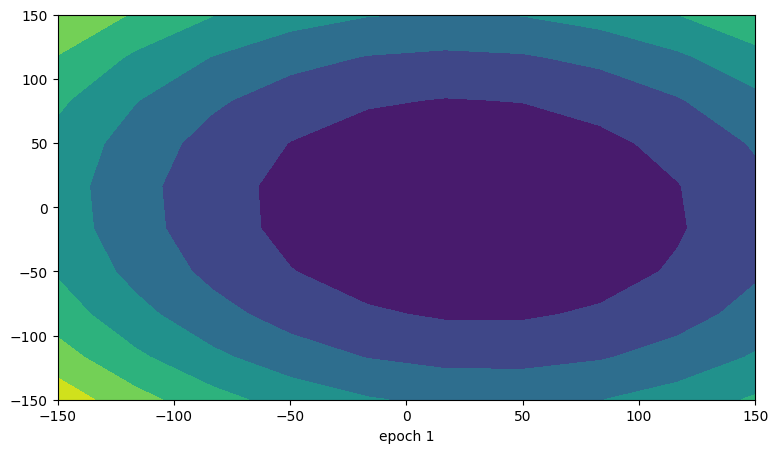

In [50]:
%matplotlib inline
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

# intercept graph
num_epochs = list(range(0,30))
fig = plt.figure(figsize=(9,5)) 
axis = plt.axes(xlim =(-150, 150), ylim =(-150, 150)) 

axis.contourf(m_arr, b_arr, z_arr)

line, = axis.plot([], [], lw = 2,color='white') 
  
xdata, ydata = [], [] 
  
# animation function 
def animate(i): 
    label = 'epoch {0}'.format(i + 1)
    xdata.append(all_m[i]) 
    ydata.append(all_b[i]) 
    line.set_data(xdata, ydata) 
    axis.set_xlabel(label)
      
    return line, 
  
# calling the animation function     
anim = animation.FuncAnimation(fig, animate, frames = 100,repeat=False, interval = 100)

#f = r"stochastic_animation_contour_plot.gif" 
#writergif = animation.PillowWriter(fps=2) 
#anim.save(f, writer=writergif